### Game Theory Assumptions - Kuhn Poker  ###

1) We will have a deck of only 3 cards - Jack, Queen King
2) We will only have 2 players 
3) Each Player has a set amount of chips of their choosing 
4) Jack < Queen < King
### Definitions ###
check - skips your turn and if both players check, the person with the higher card wins 
bet - place money or more money into the pot 
pot - place where you place the money (like a temorary bank)
### Starting the game ###
Intitial: Each player will enter a chip with equal amounts of money and be dealt a card each (2 cards dealth, 1 card hidden)
Betting round 1:
1) Player 1 acts first either choosing to check or bet 1 chip.
2) If player 1 checks then player 2 can check or bet.
3) If player 2 bets after player 1, P1 can fold or call.
4) If player 1 bets, player 2 can fold or call.
5) If at anypoint player 1 then player 2 checks, a showdown happens and it is revealed who has the higher card.
6) If at any point wither player folds, the other player gets whats in the pot (wins).
7) We repeat this for multiple rounds.



In [6]:
"""
Kuhn Poker payoff matrix generator.

This automates exactly what we did by hand:
  1. For a FIXED pair of strategies, trace all 6 card deals and average
     the payoffs (the "+1/6" calculation).
  2. Enumerate every pure strategy for each player.
  3. Run step 1 for every (P1 strategy, P2 strategy) pair to build the
     full payoff matrix A, where A[i][j] = expected payoff to P1.

By hand, you should still: derive the game tree, identify info sets,
and trace 1-2 deals manually to sanity-check this code against your
own numbers before trusting the full matrix.
"""

from itertools import product
import numpy as np

CARDS = ["J", "Q", "K"]
RANK = {"J": 0, "Q": 1, "K": 2}

# All 6 equally likely deals: every ordered pair of distinct cards
DEALS = [(p1c, p2c) for p1c in CARDS for p2c in CARDS if p1c != p2c]
DEAL_PROB = 1 / len(DEALS)  # = 1/6


def trace_payoff(p1c, p2c, p1_strategy, p2_strategy):
    """
    Walk one specific card deal under one fixed pair of strategies.
    Returns P1's net chip payoff for this single deal.

    p1_strategy = {
        "act1": {card: "bet"/"check"},          # P1's opening action
        "act2": {card: "fold"/"call"},          # P1's response if P1 checked and P2 bets
    }
    p2_strategy = {
        "vs_check": {card: "check"/"bet"},      # P2's action if P1 checked
        "vs_bet":   {card: "fold"/"call"},      # P2's action if P1 bet
    }
    """
    pot = 2          # both antes already in
    p1_contrib = 1
    p2_contrib = 1

    a1 = p1_strategy["act1"][p1c]

    if a1 == "bet":
        pot += 1
        p1_contrib += 1
        a2 = p2_strategy["vs_bet"][p2c]
        if a2 == "fold":
            return pot - p1_contrib          # P1 takes the pot
        else:  # call
            pot += 1
            p2_contrib += 1
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:  # a1 == "check"
        a2 = p2_strategy["vs_check"][p2c]
        if a2 == "check":
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:  # P2 bets
            pot += 1
            p2_contrib += 1
            a1b = p1_strategy["act2"][p1c]
            if a1b == "fold":
                return -p1_contrib
            else:  # call
                pot += 1
                p1_contrib += 1
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib


def expected_payoff(p1_strategy, p2_strategy):
    """Average trace_payoff over all 6 deals -- this is one matrix cell."""
    total = sum(
        trace_payoff(p1c, p2c, p1_strategy, p2_strategy)
        for (p1c, p2c) in DEALS
    )
    return total * DEAL_PROB


def all_p1_strategies():
    """Enumerate every pure strategy for P1: 2^3 (act1) x 2^3 (act2) = 64 raw combos."""
    act1_options = list(product(["bet", "check"], repeat=3))
    act2_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for a1 in act1_options:
        for a2 in act2_options:
            strategies.append({
                "act1": dict(zip(CARDS, a1)),
                "act2": dict(zip(CARDS, a2)),
            })
    return strategies


def all_p2_strategies():
    """Enumerate every pure strategy for P2: 2^3 (vs_check) x 2^3 (vs_bet) = 64 combos."""
    vs_check_options = list(product(["check", "bet"], repeat=3))
    vs_bet_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for vc in vs_check_options:
        for vb in vs_bet_options:
            strategies.append({
                "vs_check": dict(zip(CARDS, vc)),
                "vs_bet": dict(zip(CARDS, vb)),
            })
    return strategies


def strategy_label(strategy, player):
    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def build_payoff_matrix(p1_strategies, p2_strategies):
    """Build the full m x n payoff matrix as a list of lists."""
    matrix = []
    for s1 in p1_strategies:
        row = [expected_payoff(s1, s2) for s2 in p2_strategies]
        matrix.append(row)
    return matrix


def build_payoff_matrix_np(p1_strategies, p2_strategies):
    """
    Same as build_payoff_matrix, but returns a numpy array directly.
    This is the form you'll feed into scipy.optimize.linprog later.
    """
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff(s1, s2)
    return matrix


def display_matrix(matrix, p1_strategies, p2_strategies, max_rows=10, max_cols=10):
    """
    Pretty-print a numpy payoff matrix with row/column strategy labels,
    aligned into a readable table. Truncates to max_rows x max_cols by
    default since the full 64x64 matrix is too wide to read comfortably.
    """
    m, n = matrix.shape
    show_rows = min(m, max_rows)
    show_cols = min(n, max_cols)

    row_labels = [strategy_label(s, 1) for s in p1_strategies[:show_rows]]
    col_labels = [strategy_label(s, 2) for s in p2_strategies[:show_cols]]

    row_label_width = max(len(lbl) for lbl in row_labels) + 2
    col_width = max(max(len(lbl) for lbl in col_labels), 8) + 2

    # Header row
    header = " " * row_label_width + "".join(f"{lbl:>{col_width}}" for lbl in col_labels)
    print(header)
    print("-" * len(header))

    # Body rows
    for i in range(show_rows):
        row_str = f"{row_labels[i]:<{row_label_width}}"
        for j in range(show_cols):
            row_str += f"{matrix[i, j]:>+{col_width}.3f}"
        print(row_str)

    if m > show_rows or n > show_cols:
        print(f"\n(showing {show_rows}x{show_cols} of full {m}x{n} matrix)")


if __name__ == "__main__":
    # Sanity check: reproduce the exact hand-computed example (+1/6)
    p1_example = {
        "act1": {"J": "check", "Q": "check", "K": "bet"},
        "act2": {"J": "fold", "Q": "fold", "K": "call"},
    }
    p2_example = {
        "vs_check": {"J": "check", "Q": "check", "K": "bet"},
        "vs_bet": {"J": "fold", "Q": "call", "K": "call"},
    }
    result = expected_payoff(p1_example, p2_example)
    print(f"Sanity check (should match hand calc ~0.1667): {result:.4f}")

    # Full enumeration -- this is the part that would take forever by hand
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    print(f"\nTotal P1 strategies: {len(p1_strats)}")
    print(f"Total P2 strategies: {len(p2_strats)}")
    print(f"Full matrix size: {len(p1_strats)} x {len(p2_strats)} = {len(p1_strats)*len(p2_strats)} cells")

    matrix = build_payoff_matrix_np(p1_strats, p2_strats)
    print(f"\nMatrix type: {type(matrix)}, shape: {matrix.shape}, dtype: {matrix.dtype}")

    print("\nPretty-printed corner of the payoff matrix (P1's expected payoff):")
    display_matrix(matrix, p1_strats, p2_strats, max_rows=6, max_cols=6)

Sanity check (should match hand calc ~0.1667): 0.1667

Total P1 strategies: 64
Total P2 strategies: 64
Full matrix size: 64 x 64 = 4096 cells

Matrix type: <class 'numpy.ndarray'>, shape: (64, 64), dtype: float64

Pretty-printed corner of the payoff matrix (P1's expected payoff):
                     J:c/f,Q:c/f,K:c/f  J:c/f,Q:c/f,K:c/c  J:c/f,Q:c/c,K:c/f  J:c/f,Q:c/c,K:c/c  J:c/c,Q:c/f,K:c/f  J:c/c,Q:c/f,K:c/c
-------------------------------------------------------------------------------------------------------------------------------------
J:b/f,Q:b/f,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/f,K:b/c               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/c               +1.000           

In [1]:
#Comparision with AI (Claude - Sonnet 4.6)
"""
Kuhn Poker payoff matrix generator.

This automates exactly what we did by hand:
  1. For a FIXED pair of strategies, trace all 6 card deals and average
     the payoffs (the "+1/6" calculation).
  2. Enumerate every pure strategy for each player.
  3. Run step 1 for every (P1 strategy, P2 strategy) pair to build the
     full payoff matrix A, where A[i][j] = expected payoff to P1.

By hand, you should still: derive the game tree, identify info sets,
and trace 1-2 deals manually to sanity-check this code against your
own numbers before trusting the full matrix.
"""

from itertools import product
import numpy as np

CARDS = ["J", "Q", "K"]
RANK = {"J": 0, "Q": 1, "K": 2}

# All 6 equally likely deals: every ordered pair of distinct cards
DEALS = [(p1c, p2c) for p1c in CARDS for p2c in CARDS if p1c != p2c]
DEAL_PROB = 1 / len(DEALS)  # = 1/6


def trace_payoff(p1c, p2c, p1_strategy, p2_strategy):
    """
    Walk one specific card deal under one fixed pair of strategies.
    Returns P1's net chip payoff for this single deal.

    p1_strategy = {
        "act1": {card: "bet"/"check"},          # P1's opening action
        "act2": {card: "fold"/"call"},          # P1's response if P1 checked and P2 bets
    }
    p2_strategy = {
        "vs_check": {card: "check"/"bet"},      # P2's action if P1 checked
        "vs_bet":   {card: "fold"/"call"},      # P2's action if P1 bet
    }
    """
    pot = 2          # both antes already in
    p1_contrib = 1
    p2_contrib = 1

    a1 = p1_strategy["act1"][p1c]

    if a1 == "bet":
        pot += 1
        p1_contrib += 1
        a2 = p2_strategy["vs_bet"][p2c]
        if a2 == "fold":
            return pot - p1_contrib          # P1 takes the pot
        else:  # call
            pot += 1
            p2_contrib += 1
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:  # a1 == "check"
        a2 = p2_strategy["vs_check"][p2c]
        if a2 == "check":
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:  # P2 bets
            pot += 1
            p2_contrib += 1
            a1b = p1_strategy["act2"][p1c]
            if a1b == "fold":
                return -p1_contrib
            else:  # call
                pot += 1
                p1_contrib += 1
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib


def expected_payoff(p1_strategy, p2_strategy):
    """Average trace_payoff over all 6 deals -- this is one matrix cell."""
    total = sum(
        trace_payoff(p1c, p2c, p1_strategy, p2_strategy)
        for (p1c, p2c) in DEALS
    )
    return total * DEAL_PROB


def mixed_expected_payoff(p1_mixed, p2_mixed):
    """
    Same idea as expected_payoff(), but for MIXED (probabilistic) strategies
    instead of pure ones. Needed to validate against the published Kuhn
    poker Nash equilibrium, which is mixed (e.g. "bet with J with
    probability alpha"), not a fixed action.

    p1_mixed = {
        "bet_prob":  {card: P(P1 bets with this card)},
        "call_prob": {card: P(P1 calls, given P1 checked and P2 bet)},
    }
    p2_mixed = {
        "bet_prob_vs_check": {card: P(P2 bets, given P1 checked)},
        "call_prob_vs_bet":  {card: P(P2 calls, given P1 bet)},
    }

    Works by computing the (fixed) payoff at each of the 5 distinct leaf
    types directly, then weighting them by the probability of reaching
    each leaf -- rather than branching on a single sampled action.
    """
    total = 0.0
    for p1c, p2c in DEALS:
        p1_wins = RANK[p1c] > RANK[p2c]

        b1 = p1_mixed["bet_prob"][p1c]            # P(P1 bets)
        f1 = p1_mixed["call_prob"][p1c]            # P(P1 calls | checked, faced bet)
        b2 = p2_mixed["bet_prob_vs_check"][p2c]     # P(P2 bets | P1 checked)
        c2 = p2_mixed["call_prob_vs_bet"][p2c]      # P(P2 calls | P1 bet)

        # Leaf payoffs (same chip accounting as trace_payoff)
        payoff_bet_fold = 1                                    # pot=3, p1_contrib=2
        payoff_bet_call = 2 if p1_wins else -2                  # pot=4, p1_contrib=2
        payoff_check_check = 1 if p1_wins else -1                # pot=2, p1_contrib=1
        payoff_check_bet_fold = -1                                # only ante lost
        payoff_check_bet_call = 2 if p1_wins else -2              # pot=4, p1_contrib=2

        branch_bet = c2 * payoff_bet_call + (1 - c2) * payoff_bet_fold
        branch_check = (1 - b2) * payoff_check_check + b2 * (
            f1 * payoff_check_bet_call + (1 - f1) * payoff_check_bet_fold
        )

        deal_ev = b1 * branch_bet + (1 - b1) * branch_check
        total += deal_ev

    return total * DEAL_PROB


def kuhn_equilibrium(alpha):
    """
    The published closed-form Kuhn poker Nash equilibrium, parameterised by
    alpha in [0, 1/3] -- P1's probability of bluff-betting with a Jack.
    Returns (p1_mixed, p2_mixed) ready for mixed_expected_payoff().
    """
    p1_mixed = {
        "bet_prob": {"J": alpha, "Q": 0.0, "K": 3 * alpha},
        "call_prob": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    p2_mixed = {
        "bet_prob_vs_check": {"J": 1 / 3, "Q": 0.0, "K": 1.0},
        "call_prob_vs_bet": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    return p1_mixed, p2_mixed



def all_p1_strategies():
    """Enumerate every pure strategy for P1: 2^3 (act1) x 2^3 (act2) = 64 raw combos."""
    act1_options = list(product(["bet", "check"], repeat=3))
    act2_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for a1 in act1_options:
        for a2 in act2_options:
            strategies.append({
                "act1": dict(zip(CARDS, a1)),
                "act2": dict(zip(CARDS, a2)),
            })
    return strategies


def all_p2_strategies():
    """Enumerate every pure strategy for P2: 2^3 (vs_check) x 2^3 (vs_bet) = 64 combos."""
    vs_check_options = list(product(["check", "bet"], repeat=3))
    vs_bet_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for vc in vs_check_options:
        for vb in vs_bet_options:
            strategies.append({
                "vs_check": dict(zip(CARDS, vc)),
                "vs_bet": dict(zip(CARDS, vb)),
            })
    return strategies


def strategy_label(strategy, player):
    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def build_payoff_matrix(p1_strategies, p2_strategies):
    """Build the full m x n payoff matrix as a list of lists."""
    matrix = []
    for s1 in p1_strategies:
        row = [expected_payoff(s1, s2) for s2 in p2_strategies]
        matrix.append(row)
    return matrix


def build_payoff_matrix_np(p1_strategies, p2_strategies):
    """
    Same as build_payoff_matrix, but returns a numpy array directly.
    This is the form you'll feed into scipy.optimize.linprog later.
    """
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff(s1, s2)
    return matrix


def display_matrix(matrix, p1_strategies, p2_strategies, max_rows=10, max_cols=10):
    """
    Pretty-print a numpy payoff matrix with row/column strategy labels,
    aligned into a readable table. Truncates to max_rows x max_cols by
    default since the full 64x64 matrix is too wide to read comfortably.
    """
    m, n = matrix.shape
    show_rows = min(m, max_rows)
    show_cols = min(n, max_cols)

    row_labels = [strategy_label(s, 1) for s in p1_strategies[:show_rows]]
    col_labels = [strategy_label(s, 2) for s in p2_strategies[:show_cols]]

    row_label_width = max(len(lbl) for lbl in row_labels) + 2
    col_width = max(max(len(lbl) for lbl in col_labels), 8) + 2

    # Header row
    header = " " * row_label_width + "".join(f"{lbl:>{col_width}}" for lbl in col_labels)
    print(header)
    print("-" * len(header))

    # Body rows
    for i in range(show_rows):
        row_str = f"{row_labels[i]:<{row_label_width}}"
        for j in range(show_cols):
            row_str += f"{matrix[i, j]:>+{col_width}.3f}"
        print(row_str)

    if m > show_rows or n > show_cols:
        print(f"\n(showing {show_rows}x{show_cols} of full {m}x{n} matrix)")


if __name__ == "__main__":
    # Sanity check: reproduce the exact hand-computed example (+1/6)
    p1_example = {
        "act1": {"J": "check", "Q": "check", "K": "bet"},
        "act2": {"J": "fold", "Q": "fold", "K": "call"},
    }
    p2_example = {
        "vs_check": {"J": "check", "Q": "check", "K": "bet"},
        "vs_bet": {"J": "fold", "Q": "call", "K": "call"},
    }
    result = expected_payoff(p1_example, p2_example)
    print(f"Sanity check (should match hand calc ~0.1667): {result:.4f}")

    # Validate against the PUBLISHED Kuhn poker Nash equilibrium (mixed strategy)
    alpha = 1 / 6  # canonical midpoint of the valid range [0, 1/3]
    p1_eq, p2_eq = kuhn_equilibrium(alpha)
    game_value = mixed_expected_payoff(p1_eq, p2_eq)
    print(f"\nPublished equilibrium game value (alpha={alpha:.4f}): {game_value:.4f}")
    print(f"Expected (known result): -1/18 = {-1/18:.4f}")
    print(f"Match: {abs(game_value - (-1/18)) < 1e-9}")


    # Full enumeration -- this is the part that would take forever by hand
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    print(f"\nTotal P1 strategies: {len(p1_strats)}")
    print(f"Total P2 strategies: {len(p2_strats)}")
    print(f"Full matrix size: {len(p1_strats)} x {len(p2_strats)} = {len(p1_strats)*len(p2_strats)} cells")

    matrix = build_payoff_matrix_np(p1_strats, p2_strats)
    print(f"\nMatrix type: {type(matrix)}, shape: {matrix.shape}, dtype: {matrix.dtype}")

    print("\nPretty-printed corner of the payoff matrix (P1's expected payoff):")
    display_matrix(matrix, p1_strats, p2_strats, max_rows=6, max_cols=6)

Sanity check (should match hand calc ~0.1667): 0.1667

Published equilibrium game value (alpha=0.1667): -0.0556
Expected (known result): -1/18 = -0.0556
Match: True

Total P1 strategies: 64
Total P2 strategies: 64
Full matrix size: 64 x 64 = 4096 cells

Matrix type: <class 'numpy.ndarray'>, shape: (64, 64), dtype: float64

Pretty-printed corner of the payoff matrix (P1's expected payoff):
                     J:c/f,Q:c/f,K:c/f  J:c/f,Q:c/f,K:c/c  J:c/f,Q:c/c,K:c/f  J:c/f,Q:c/c,K:c/c  J:c/c,Q:c/f,K:c/f  J:c/c,Q:c/f,K:c/c
-------------------------------------------------------------------------------------------------------------------------------------
J:b/f,Q:b/f,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/f,K:b/c               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/f               +1.000             +0.000             +0

### Comparision Insights ###
Matrix had slight differences, AI added a validation check to show the expected value of -1/18 which helps as it suggests being P2 has a slight probabilistic advantage.

In [3]:
matrix

array([[ 1.        ,  0.        ,  0.66666667, ...,  0.33333333,
         1.        ,  0.        ],
       [ 1.        ,  0.        ,  0.66666667, ...,  0.33333333,
         1.        ,  0.        ],
       [ 1.        ,  0.        ,  0.66666667, ...,  0.33333333,
         1.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.33333333,
        -0.33333333, -0.33333333],
       [ 0.        ,  0.        ,  0.        , ..., -1.        ,
        -1.        , -1.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(64, 64))

In [12]:
"""
Kuhn Poker payoff matrix generator.

This automates exactly what we did by hand:
  1. For a FIXED pair of strategies, trace all 6 card deals and average
     the payoffs (the "+1/6" calculation).
  2. Enumerate every pure strategy for each player.
  3. Run step 1 for every (P1 strategy, P2 strategy) pair to build the
     full payoff matrix A, where A[i][j] = expected payoff to P1.

By hand, you should still: derive the game tree, identify info sets,
and trace 1-2 deals manually to sanity-check this code against your
own numbers before trusting the full matrix.
"""

from itertools import product
import numpy as np
from scipy.optimize import linprog

CARDS = ["J", "Q", "K"]
RANK = {"J": 0, "Q": 1, "K": 2}

# All 6 equally likely deals: every ordered pair of distinct cards
DEALS = [(p1c, p2c) for p1c in CARDS for p2c in CARDS if p1c != p2c]
DEAL_PROB = 1 / len(DEALS)  # = 1/6


def trace_payoff(p1c, p2c, p1_strategy, p2_strategy):
    """
    Walk one specific card deal under one fixed pair of strategies.
    Returns P1's net chip payoff for this single deal.

    p1_strategy = {
        "act1": {card: "bet"/"check"},          # P1's opening action
        "act2": {card: "fold"/"call"},          # P1's response if P1 checked and P2 bets
    }
    p2_strategy = {
        "vs_check": {card: "check"/"bet"},      # P2's action if P1 checked
        "vs_bet":   {card: "fold"/"call"},      # P2's action if P1 bet
    }
    """
    pot = 2          # both antes already in
    p1_contrib = 1
    p2_contrib = 1

    a1 = p1_strategy["act1"][p1c]

    if a1 == "bet":
        pot += 1
        p1_contrib += 1
        a2 = p2_strategy["vs_bet"][p2c]
        if a2 == "fold":
            return pot - p1_contrib          # P1 takes the pot
        else:  # call
            pot += 1
            p2_contrib += 1
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:  # a1 == "check"
        a2 = p2_strategy["vs_check"][p2c]
        if a2 == "check":
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:  # P2 bets
            pot += 1
            p2_contrib += 1
            a1b = p1_strategy["act2"][p1c]
            if a1b == "fold":
                return -p1_contrib
            else:  # call
                pot += 1
                p1_contrib += 1
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib



In [13]:

def expected_payoff(p1_strategy, p2_strategy):
    """Average trace_payoff over all 6 deals -- this is one matrix cell."""
    total = sum(
        trace_payoff(p1c, p2c, p1_strategy, p2_strategy)
        for (p1c, p2c) in DEALS
    )
    return total * DEAL_PROB


def mixed_expected_payoff(p1_mixed, p2_mixed):
    """
    Same idea as expected_payoff(), but for MIXED (probabilistic) strategies
    instead of pure ones. Needed to validate against the published Kuhn
    poker Nash equilibrium, which is mixed (e.g. "bet with J with
    probability alpha"), not a fixed action.

    p1_mixed = {
        "bet_prob":  {card: P(P1 bets with this card)},
        "call_prob": {card: P(P1 calls, given P1 checked and P2 bet)},
    }
    p2_mixed = {
        "bet_prob_vs_check": {card: P(P2 bets, given P1 checked)},
        "call_prob_vs_bet":  {card: P(P2 calls, given P1 bet)},
    }

    Works by computing the (fixed) payoff at each of the 5 distinct leaf
    types directly, then weighting them by the probability of reaching
    each leaf -- rather than branching on a single sampled action.
    """
    total = 0.0
    for p1c, p2c in DEALS:
        p1_wins = RANK[p1c] > RANK[p2c]

        b1 = p1_mixed["bet_prob"][p1c]            # P(P1 bets)
        f1 = p1_mixed["call_prob"][p1c]            # P(P1 calls | checked, faced bet)
        b2 = p2_mixed["bet_prob_vs_check"][p2c]     # P(P2 bets | P1 checked)
        c2 = p2_mixed["call_prob_vs_bet"][p2c]      # P(P2 calls | P1 bet)

        # Leaf payoffs (same chip accounting as trace_payoff)
        payoff_bet_fold = 1                                    # pot=3, p1_contrib=2
        payoff_bet_call = 2 if p1_wins else -2                  # pot=4, p1_contrib=2
        payoff_check_check = 1 if p1_wins else -1                # pot=2, p1_contrib=1
        payoff_check_bet_fold = -1                                # only ante lost
        payoff_check_bet_call = 2 if p1_wins else -2              # pot=4, p1_contrib=2

        branch_bet = c2 * payoff_bet_call + (1 - c2) * payoff_bet_fold
        branch_check = (1 - b2) * payoff_check_check + b2 * (
            f1 * payoff_check_bet_call + (1 - f1) * payoff_check_bet_fold
        )

        deal_ev = b1 * branch_bet + (1 - b1) * branch_check
        total += deal_ev

    return total * DEAL_PROB



In [14]:

def kuhn_equilibrium(alpha):
    """
    The published closed-form Kuhn poker Nash equilibrium, parameterised by
    alpha in [0, 1/3] -- P1's probability of bluff-betting with a Jack.
    Returns (p1_mixed, p2_mixed) ready for mixed_expected_payoff().
    """
    p1_mixed = {
        "bet_prob": {"J": alpha, "Q": 0.0, "K": 3 * alpha},
        "call_prob": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    p2_mixed = {
        "bet_prob_vs_check": {"J": 1 / 3, "Q": 0.0, "K": 1.0},
        "call_prob_vs_bet": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    return p1_mixed, p2_mixed




In [15]:
#added an Primal LP solver, AI used for structure, documentaiion and in-line comments 
def solve_primal_lp(A):
    """
    Solve P1's maximin LP using scipy.optimize.linprog.

    Primal (as derived):
        max_{x,v}  v
        s.t.       sum_i x_i * A[i][j] >= v   for every column j
                    sum_i x_i = 1
                    x_i >= 0

    linprog only minimises and only accepts <= constraints, so this gets
    translated mechanically:
        - maximise v  ->  minimise -v
        - sum_i x_i*A[i][j] >= v  ->  -sum_i x_i*A[i][j] + v <= 0

    Returns:
        x: P1's optimal mixed strategy (probability per row/strategy)
        v: the guaranteed game value to P1
        y: P2's optimal mixed strategy, recovered from the dual values
        w: the dual objective (should equal v, by strong duality)
        res: the raw linprog result object
    """
    m, n = A.shape

    # Variables are [x_1, ..., x_m, v] -- length m+1
    c = np.zeros(m + 1)
    c[-1] = -1  # minimise -v == maximise v

    # One <= constraint per column j: -A[:,j]^T x + v <= 0
    A_ub = np.hstack([-A.T, np.ones((n, 1))])
    b_ub = np.zeros(n)

    # Equality: sum_i x_i = 1
    A_eq = np.zeros((1, m + 1))
    A_eq[0, :m] = 1
    b_eq = [1]

    # x_i >= 0 ; v is unrestricted in sign
    bounds = [(0, None)] * m + [(None, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                   bounds=bounds, method="highs")

    x = res.x[:m]
    v = res.x[-1]

    # Dual values for the column constraints ARE P2's optimal strategy y
    # (this is the "free" dual output strong duality promised us).
    # highs reports marginals as <= 0 for <= constraints; flip sign to get
    # a proper non-negative probability vector.
    y = -res.ineqlin.marginals
    w = v  # strong duality guarantees these are equal; verified numerically below

    return x, v, y, w, res




In [16]:

def all_p1_strategies():
    """Enumerate every pure strategy for P1: 2^3 (act1) x 2^3 (act2) = 64 raw combos."""
    act1_options = list(product(["bet", "check"], repeat=3))
    act2_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for a1 in act1_options:
        for a2 in act2_options:
            strategies.append({
                "act1": dict(zip(CARDS, a1)),
                "act2": dict(zip(CARDS, a2)),
            })
    return strategies


def all_p2_strategies():
    """Enumerate every pure strategy for P2: 2^3 (vs_check) x 2^3 (vs_bet) = 64 combos."""
    vs_check_options = list(product(["check", "bet"], repeat=3))
    vs_bet_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for vc in vs_check_options:
        for vb in vs_bet_options:
            strategies.append({
                "vs_check": dict(zip(CARDS, vc)),
                "vs_bet": dict(zip(CARDS, vb)),
            })
    return strategies


def strategy_label(strategy, player):
    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)



In [17]:

def build_payoff_matrix(p1_strategies, p2_strategies):
    """Build the full m x n payoff matrix as a list of lists."""
    matrix = []
    for s1 in p1_strategies:
        row = [expected_payoff(s1, s2) for s2 in p2_strategies]
        matrix.append(row)
    return matrix


def build_payoff_matrix_np(p1_strategies, p2_strategies):
    """
    Same as build_payoff_matrix, but returns a numpy array directly.
    This is the form you'll feed into scipy.optimize.linprog later.
    """
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff(s1, s2)
    return matrix


def display_matrix(matrix, p1_strategies, p2_strategies, max_rows=10, max_cols=10):
    """
    Pretty-print a numpy payoff matrix with row/column strategy labels,
    aligned into a readable table. Truncates to max_rows x max_cols by
    default since the full 64x64 matrix is too wide to read comfortably.
    """
    m, n = matrix.shape
    show_rows = min(m, max_rows)
    show_cols = min(n, max_cols)

    row_labels = [strategy_label(s, 1) for s in p1_strategies[:show_rows]]
    col_labels = [strategy_label(s, 2) for s in p2_strategies[:show_cols]]

    row_label_width = max(len(lbl) for lbl in row_labels) + 2
    col_width = max(max(len(lbl) for lbl in col_labels), 8) + 2

    # Header row
    header = " " * row_label_width + "".join(f"{lbl:>{col_width}}" for lbl in col_labels)
    print(header)
    print("-" * len(header))

    # Body rows
    for i in range(show_rows):
        row_str = f"{row_labels[i]:<{row_label_width}}"
        for j in range(show_cols):
            row_str += f"{matrix[i, j]:>+{col_width}.3f}"
        print(row_str)

    if m > show_rows or n > show_cols:
        print(f"\n(showing {show_rows}x{show_cols} of full {m}x{n} matrix)")


if __name__ == "__main__":
    # Sanity check: reproduce the exact hand-computed example (+1/6)
    p1_example = {
        "act1": {"J": "check", "Q": "check", "K": "bet"},
        "act2": {"J": "fold", "Q": "fold", "K": "call"},
    }
    p2_example = {
        "vs_check": {"J": "check", "Q": "check", "K": "bet"},
        "vs_bet": {"J": "fold", "Q": "call", "K": "call"},
    }
    result = expected_payoff(p1_example, p2_example)
    print(f"Sanity check (should match hand calc ~0.1667): {result:.4f}")

    # Validate against the PUBLISHED Kuhn poker Nash equilibrium (mixed strategy)
    alpha = 1 / 6  # canonical midpoint of the valid range [0, 1/3]
    p1_eq, p2_eq = kuhn_equilibrium(alpha)
    game_value = mixed_expected_payoff(p1_eq, p2_eq)
    print(f"\nPublished equilibrium game value (alpha={alpha:.4f}): {game_value:.4f}")
    print(f"Expected (known result): -1/18 = {-1/18:.4f}")
    print(f"Match: {abs(game_value - (-1/18)) < 1e-9}")


    # Full enumeration -- this is the part that would take forever by hand
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    print(f"\nTotal P1 strategies: {len(p1_strats)}")
    print(f"Total P2 strategies: {len(p2_strats)}")
    print(f"Full matrix size: {len(p1_strats)} x {len(p2_strats)} = {len(p1_strats)*len(p2_strats)} cells")

    matrix = build_payoff_matrix_np(p1_strats, p2_strats)
    print(f"\nMatrix type: {type(matrix)}, shape: {matrix.shape}, dtype: {matrix.dtype}")

    print("\nPretty-printed corner of the payoff matrix (P1's expected payoff):")
    display_matrix(matrix, p1_strats, p2_strats, max_rows=6, max_cols=6)

    # --- Week 2: solve the primal LP and recover the dual ---
    x, v, y, w, res = solve_primal_lp(matrix)
    print(f"\nLP status: {res.message}")
    print(f"Guaranteed game value to P1 (v): {v:.4f}")
    print(f"Dual game value to P2 (w):       {w:.4f}")
    print(f"Compare to known value -1/18:    {-1/18:.4f}")
    print(f"x sums to 1: {x.sum():.6f}   y sums to 1: {y.sum():.6f}")

    print("\nP1's solved strategy -- top 5 strategies by probability:")
    top_p1 = np.argsort(-x)[:5]
    for idx in top_p1:
        print(f"  x={x[idx]:.4f}  {strategy_label(p1_strats[idx], 1)}")

    print("\nP2's solved strategy -- top 5 strategies by probability:")
    top_p2 = np.argsort(-y)[:5]
    for idx in top_p2:
        print(f"  y={y[idx]:.4f}  {strategy_label(p2_strats[idx], 2)}")

Sanity check (should match hand calc ~0.1667): 0.1667

Published equilibrium game value (alpha=0.1667): -0.0556
Expected (known result): -1/18 = -0.0556
Match: True

Total P1 strategies: 64
Total P2 strategies: 64
Full matrix size: 64 x 64 = 4096 cells

Matrix type: <class 'numpy.ndarray'>, shape: (64, 64), dtype: float64

Pretty-printed corner of the payoff matrix (P1's expected payoff):
                     J:c/f,Q:c/f,K:c/f  J:c/f,Q:c/f,K:c/c  J:c/f,Q:c/c,K:c/f  J:c/f,Q:c/c,K:c/c  J:c/c,Q:c/f,K:c/f  J:c/c,Q:c/f,K:c/c
-------------------------------------------------------------------------------------------------------------------------------------
J:b/f,Q:b/f,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/f,K:b/c               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/f               +1.000             +0.000             +0

In [18]:
"""
Kuhn Poker payoff matrix generator.

This automates exactly what we did by hand:
  1. For a FIXED pair of strategies, trace all 6 card deals and average
     the payoffs (the "+1/6" calculation).
  2. Enumerate every pure strategy for each player.
  3. Run step 1 for every (P1 strategy, P2 strategy) pair to build the
     full payoff matrix A, where A[i][j] = expected payoff to P1.

By hand, you should still: derive the game tree, identify info sets,
and trace 1-2 deals manually to sanity-check this code against your
own numbers before trusting the full matrix.
"""

from itertools import product
import numpy as np
from scipy.optimize import linprog

CARDS = ["J", "Q", "K"]
RANK = {"J": 0, "Q": 1, "K": 2}

# All 6 equally likely deals: every ordered pair of distinct cards
DEALS = [(p1c, p2c) for p1c in CARDS for p2c in CARDS if p1c != p2c]
DEAL_PROB = 1 / len(DEALS)  # = 1/6


def trace_payoff(p1c, p2c, p1_strategy, p2_strategy):
    """
    Walk one specific card deal under one fixed pair of strategies.
    Returns P1's net chip payoff for this single deal.

    p1_strategy = {
        "act1": {card: "bet"/"check"},          # P1's opening action
        "act2": {card: "fold"/"call"},          # P1's response if P1 checked and P2 bets
    }
    p2_strategy = {
        "vs_check": {card: "check"/"bet"},      # P2's action if P1 checked
        "vs_bet":   {card: "fold"/"call"},      # P2's action if P1 bet
    }
    """
    pot = 2          # both antes already in
    p1_contrib = 1
    p2_contrib = 1

    a1 = p1_strategy["act1"][p1c]

    if a1 == "bet":
        pot += 1
        p1_contrib += 1
        a2 = p2_strategy["vs_bet"][p2c]
        if a2 == "fold":
            return pot - p1_contrib          # P1 takes the pot
        else:  # call
            pot += 1
            p2_contrib += 1
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:  # a1 == "check"
        a2 = p2_strategy["vs_check"][p2c]
        if a2 == "check":
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:  # P2 bets
            pot += 1
            p2_contrib += 1
            a1b = p1_strategy["act2"][p1c]
            if a1b == "fold":
                return -p1_contrib
            else:  # call
                pot += 1
                p1_contrib += 1
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib


def expected_payoff(p1_strategy, p2_strategy):
    """Average trace_payoff over all 6 deals -- this is one matrix cell."""
    total = sum(
        trace_payoff(p1c, p2c, p1_strategy, p2_strategy)
        for (p1c, p2c) in DEALS
    )
    return total * DEAL_PROB


def mixed_expected_payoff(p1_mixed, p2_mixed):
    """
    Same idea as expected_payoff(), but for MIXED (probabilistic) strategies
    instead of pure ones. Needed to validate against the published Kuhn
    poker Nash equilibrium, which is mixed (e.g. "bet with J with
    probability alpha"), not a fixed action.

    p1_mixed = {
        "bet_prob":  {card: P(P1 bets with this card)},
        "call_prob": {card: P(P1 calls, given P1 checked and P2 bet)},
    }
    p2_mixed = {
        "bet_prob_vs_check": {card: P(P2 bets, given P1 checked)},
        "call_prob_vs_bet":  {card: P(P2 calls, given P1 bet)},
    }

    Works by computing the (fixed) payoff at each of the 5 distinct leaf
    types directly, then weighting them by the probability of reaching
    each leaf -- rather than branching on a single sampled action.
    """
    total = 0.0
    for p1c, p2c in DEALS:
        p1_wins = RANK[p1c] > RANK[p2c]

        b1 = p1_mixed["bet_prob"][p1c]            # P(P1 bets)
        f1 = p1_mixed["call_prob"][p1c]            # P(P1 calls | checked, faced bet)
        b2 = p2_mixed["bet_prob_vs_check"][p2c]     # P(P2 bets | P1 checked)
        c2 = p2_mixed["call_prob_vs_bet"][p2c]      # P(P2 calls | P1 bet)

        # Leaf payoffs (same chip accounting as trace_payoff)
        payoff_bet_fold = 1                                    # pot=3, p1_contrib=2
        payoff_bet_call = 2 if p1_wins else -2                  # pot=4, p1_contrib=2
        payoff_check_check = 1 if p1_wins else -1                # pot=2, p1_contrib=1
        payoff_check_bet_fold = -1                                # only ante lost
        payoff_check_bet_call = 2 if p1_wins else -2              # pot=4, p1_contrib=2

        branch_bet = c2 * payoff_bet_call + (1 - c2) * payoff_bet_fold
        branch_check = (1 - b2) * payoff_check_check + b2 * (
            f1 * payoff_check_bet_call + (1 - f1) * payoff_check_bet_fold
        )

        deal_ev = b1 * branch_bet + (1 - b1) * branch_check
        total += deal_ev

    return total * DEAL_PROB


def kuhn_equilibrium(alpha):
    """
    The published closed-form Kuhn poker Nash equilibrium, parameterised by
    alpha in [0, 1/3] -- P1's probability of bluff-betting with a Jack.
    Returns (p1_mixed, p2_mixed) ready for mixed_expected_payoff().
    """
    p1_mixed = {
        "bet_prob": {"J": alpha, "Q": 0.0, "K": 3 * alpha},
        "call_prob": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    p2_mixed = {
        "bet_prob_vs_check": {"J": 1 / 3, "Q": 0.0, "K": 1.0},
        "call_prob_vs_bet": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    return p1_mixed, p2_mixed



def solve_primal_lp(A):
    """
    Solve P1's maximin LP using scipy.optimize.linprog.

    Primal (as derived):
        max_{x,v}  v
        s.t.       sum_i x_i * A[i][j] >= v   for every column j
                    sum_i x_i = 1
                    x_i >= 0

    linprog only minimises and only accepts <= constraints, so this gets
    translated mechanically:
        - maximise v  ->  minimise -v
        - sum_i x_i*A[i][j] >= v  ->  -sum_i x_i*A[i][j] + v <= 0

    Returns:
        x: P1's optimal mixed strategy (probability per row/strategy)
        v: the guaranteed game value to P1
        y: P2's optimal mixed strategy, recovered from the dual values
        w: the dual objective (should equal v, by strong duality)
        res: the raw linprog result object
    """
    m, n = A.shape

    # Variables are [x_1, ..., x_m, v] -- length m+1
    c = np.zeros(m + 1)
    c[-1] = -1  # minimise -v == maximise v

    # One <= constraint per column j: -A[:,j]^T x + v <= 0
    A_ub = np.hstack([-A.T, np.ones((n, 1))])
    b_ub = np.zeros(n)

    # Equality: sum_i x_i = 1
    A_eq = np.zeros((1, m + 1))
    A_eq[0, :m] = 1
    b_eq = [1]

    # x_i >= 0 ; v is unrestricted in sign
    bounds = [(0, None)] * m + [(None, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                   bounds=bounds, method="highs")

    x = res.x[:m]
    v = res.x[-1]

    # Dual values for the column constraints ARE P2's optimal strategy y
    # (this is the "free" dual output strong duality promised us).
    # highs reports marginals as <= 0 for <= constraints; flip sign to get
    # a proper non-negative probability vector.
    y = -res.ineqlin.marginals
    w = v  # strong duality guarantees these are equal; verified numerically below

    return x, v, y, w, res



def all_p1_strategies():
    """Enumerate every pure strategy for P1: 2^3 (act1) x 2^3 (act2) = 64 raw combos."""
    act1_options = list(product(["bet", "check"], repeat=3))
    act2_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for a1 in act1_options:
        for a2 in act2_options:
            strategies.append({
                "act1": dict(zip(CARDS, a1)),
                "act2": dict(zip(CARDS, a2)),
            })
    return strategies


def all_p2_strategies():
    """Enumerate every pure strategy for P2: 2^3 (vs_check) x 2^3 (vs_bet) = 64 combos."""
    vs_check_options = list(product(["check", "bet"], repeat=3))
    vs_bet_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for vc in vs_check_options:
        for vb in vs_bet_options:
            strategies.append({
                "vs_check": dict(zip(CARDS, vc)),
                "vs_bet": dict(zip(CARDS, vb)),
            })
    return strategies


def aggregate_p1_strategy(x, p1_strategies):
    """
    Collapse P1's solved mixed strategy (probabilities over 64 pure
    strategies) into per-card behavioral probabilities -- the same form
    the published equilibrium (alpha) is stated in. This is what lets you
    compare the LP's answer to the textbook answer number-for-number.
    """
    bet_prob = {}
    call_prob = {}
    for card in CARDS:
        p_bet = sum(x[i] for i, s in enumerate(p1_strategies) if s["act1"][card] == "bet")
        p_check = 1 - p_bet
        bet_prob[card] = p_bet

        # call_prob is conditional on having checked -- only meaningful
        # among the probability mass that actually checked with this card
        p_check_and_call = sum(
            x[i] for i, s in enumerate(p1_strategies)
            if s["act1"][card] == "check" and s["act2"][card] == "call"
        )
        call_prob[card] = (p_check_and_call / p_check) if p_check > 1e-9 else None

    return {"bet_prob": bet_prob, "call_prob": call_prob}


def aggregate_p2_strategy(y, p2_strategies):
    """Same idea as aggregate_p1_strategy, but for P2's solved mix."""
    bet_prob_vs_check = {}
    call_prob_vs_bet = {}
    for card in CARDS:
        bet_prob_vs_check[card] = sum(
            y[j] for j, s in enumerate(p2_strategies) if s["vs_check"][card] == "bet"
        )
        call_prob_vs_bet[card] = sum(
            y[j] for j, s in enumerate(p2_strategies) if s["vs_bet"][card] == "call"
        )
    return {"bet_prob_vs_check": bet_prob_vs_check, "call_prob_vs_bet": call_prob_vs_bet}



    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def strategy_label(strategy, player):
    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def build_payoff_matrix(p1_strategies, p2_strategies):
    """Build the full m x n payoff matrix as a list of lists."""
    matrix = []
    for s1 in p1_strategies:
        row = [expected_payoff(s1, s2) for s2 in p2_strategies]
        matrix.append(row)
    return matrix


def build_payoff_matrix_np(p1_strategies, p2_strategies):
    """
    Same as build_payoff_matrix, but returns a numpy array directly.
    This is the form you'll feed into scipy.optimize.linprog later.
    """
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff(s1, s2)
    return matrix


def display_matrix(matrix, p1_strategies, p2_strategies, max_rows=10, max_cols=10):
    """
    Pretty-print a numpy payoff matrix with row/column strategy labels,
    aligned into a readable table. Truncates to max_rows x max_cols by
    default since the full 64x64 matrix is too wide to read comfortably.
    """
    m, n = matrix.shape
    show_rows = min(m, max_rows)
    show_cols = min(n, max_cols)

    row_labels = [strategy_label(s, 1) for s in p1_strategies[:show_rows]]
    col_labels = [strategy_label(s, 2) for s in p2_strategies[:show_cols]]

    row_label_width = max(len(lbl) for lbl in row_labels) + 2
    col_width = max(max(len(lbl) for lbl in col_labels), 8) + 2

    # Header row
    header = " " * row_label_width + "".join(f"{lbl:>{col_width}}" for lbl in col_labels)
    print(header)
    print("-" * len(header))

    # Body rows
    for i in range(show_rows):
        row_str = f"{row_labels[i]:<{row_label_width}}"
        for j in range(show_cols):
            row_str += f"{matrix[i, j]:>+{col_width}.3f}"
        print(row_str)

    if m > show_rows or n > show_cols:
        print(f"\n(showing {show_rows}x{show_cols} of full {m}x{n} matrix)")


def solve_kuhn_poker(verbose=True):
    """
    THE WEEK 2 DELIVERABLE.

    Builds the payoff matrix, solves the primal LP, and returns:
      - x: P1's equilibrium mixed strategy (probability per pure strategy)
      - v: guaranteed game value to P1
      - y: P2's equilibrium mixed strategy, recovered as the DUAL VALUES
           (shadow prices) of the primal's column constraints
      - w: dual objective (== v, by strong duality)
      - p1_agg / p2_agg: same strategies collapsed into per-card
        probabilities, directly comparable to the published closed-form
        equilibrium

    The "shadow price" interpretation: y_j is literally the dual variable
    (Lagrange multiplier / shadow price) on the constraint "P1's expected
    payoff against P2's column j must be >= v". In a zero-sum game this
    shadow price has a clean meaning -- it IS P2's optimal probability of
    playing column j -- which is a special, elegant feature of zero-sum
    games rather than something true of LP duals in general.
    """
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    matrix = build_payoff_matrix_np(p1_strats, p2_strats)

    x, v, y, w, res = solve_primal_lp(matrix)
    p1_agg = aggregate_p1_strategy(x, p1_strats)
    p2_agg = aggregate_p2_strategy(y, p2_strats)

    if verbose:
        print(f"LP status: {res.message}")
        print(f"Game value v = w = {v:.4f}  (published value: {-1/18:.4f})\n")

        print("P1 equilibrium strategy (per card):")
        for card in CARDS:
            bet = p1_agg["bet_prob"][card]
            call = p1_agg["call_prob"][card]
            call_str = f"{call:.4f}" if call is not None else "n/a (never checks this card)"
            print(f"  {card}: P(bet)={bet:.4f}   P(call | checked & faced bet)={call_str}")

        print("\nP2 equilibrium strategy (per card) -- these are the dual values / shadow prices:")
        for card in CARDS:
            bet = p2_agg["bet_prob_vs_check"][card]
            call = p2_agg["call_prob_vs_bet"][card]
            print(f"  {card}: P(bet | P1 checked)={bet:.4f}   P(call | P1 bet)={call:.4f}")

    return {
        "x": x, "v": v, "y": y, "w": w,
        "p1_agg": p1_agg, "p2_agg": p2_agg,
        "p1_strategies": p1_strats, "p2_strategies": p2_strats,
        "matrix": matrix, "raw_result": res,
    }



if __name__ == "__main__":
    # Sanity check: reproduce the exact hand-computed example (+1/6)
    p1_example = {
        "act1": {"J": "check", "Q": "check", "K": "bet"},
        "act2": {"J": "fold", "Q": "fold", "K": "call"},
    }
    p2_example = {
        "vs_check": {"J": "check", "Q": "check", "K": "bet"},
        "vs_bet": {"J": "fold", "Q": "call", "K": "call"},
    }
    result = expected_payoff(p1_example, p2_example)
    print(f"Sanity check (should match hand calc ~0.1667): {result:.4f}")

    # Validate against the PUBLISHED Kuhn poker Nash equilibrium (mixed strategy)
    alpha = 1 / 6  # canonical midpoint of the valid range [0, 1/3]
    p1_eq, p2_eq = kuhn_equilibrium(alpha)
    game_value = mixed_expected_payoff(p1_eq, p2_eq)
    print(f"\nPublished equilibrium game value (alpha={alpha:.4f}): {game_value:.4f}")
    print(f"Expected (known result): -1/18 = {-1/18:.4f}")
    print(f"Match: {abs(game_value - (-1/18)) < 1e-9}")


    # Full enumeration -- this is the part that would take forever by hand
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    print(f"\nTotal P1 strategies: {len(p1_strats)}")
    print(f"Total P2 strategies: {len(p2_strats)}")
    print(f"Full matrix size: {len(p1_strats)} x {len(p2_strats)} = {len(p1_strats)*len(p2_strats)} cells")

    matrix = build_payoff_matrix_np(p1_strats, p2_strats)
    print(f"\nMatrix type: {type(matrix)}, shape: {matrix.shape}, dtype: {matrix.dtype}")

    print("\nPretty-printed corner of the payoff matrix (P1's expected payoff):")
    display_matrix(matrix, p1_strats, p2_strats, max_rows=6, max_cols=6)

    # --- Week 2: solve the primal LP and recover the dual ---
    x, v, y, w, res = solve_primal_lp(matrix)
    print(f"\nLP status: {res.message}")
    print(f"Guaranteed game value to P1 (v): {v:.4f}")
    print(f"Dual game value to P2 (w):       {w:.4f}")
    print(f"Compare to known value -1/18:    {-1/18:.4f}")
    print(f"x sums to 1: {x.sum():.6f}   y sums to 1: {y.sum():.6f}")

    print("\nP1's solved strategy -- top 5 strategies by probability:")
    top_p1 = np.argsort(-x)[:5]
    for idx in top_p1:
        print(f"  x={x[idx]:.4f}  {strategy_label(p1_strats[idx], 1)}")

    print("\nP2's solved strategy -- top 5 strategies by probability:")
    top_p2 = np.argsort(-y)[:5]
    for idx in top_p2:
        print(f"  y={y[idx]:.4f}  {strategy_label(p2_strats[idx], 2)}")

    # --- Aggregate into per-card probabilities and compare to published equilibrium ---
    p1_agg = aggregate_p1_strategy(x, p1_strats)
    p2_agg = aggregate_p2_strategy(y, p2_strats)

    alpha_recovered = p1_agg["bet_prob"]["J"]  # P1's J-bet frequency IS alpha by definition
    p1_eq_check, p2_eq_check = kuhn_equilibrium(alpha_recovered)

    print(f"\nRecovered alpha (P1's bluff-betting frequency with J): {alpha_recovered:.4f}")
    print(f"Valid range for alpha is [0, 1/3] = [0.0000, {1/3:.4f}]\n")

    print(f"{'Quantity':<35}{'LP solved':>12}{'Published (this alpha)':>25}")
    print("-" * 72)
    rows = [
        ("P1 bet_prob[J] (alpha)", p1_agg["bet_prob"]["J"], p1_eq_check["bet_prob"]["J"]),
        ("P1 bet_prob[Q]", p1_agg["bet_prob"]["Q"], p1_eq_check["bet_prob"]["Q"]),
        ("P1 bet_prob[K] (should be 3*alpha)", p1_agg["bet_prob"]["K"], p1_eq_check["bet_prob"]["K"]),
        ("P1 call_prob[Q] (should be 1/3)", p1_agg["call_prob"]["Q"], p1_eq_check["call_prob"]["Q"]),
        ("P2 bet_vs_check[J] (should be 1/3)", p2_agg["bet_prob_vs_check"]["J"], p2_eq_check["bet_prob_vs_check"]["J"]),
        ("P2 bet_vs_check[K] (should be 1)", p2_agg["bet_prob_vs_check"]["K"], p2_eq_check["bet_prob_vs_check"]["K"]),
        ("P2 call_vs_bet[Q] (should be 1/3)", p2_agg["call_prob_vs_bet"]["Q"], p2_eq_check["call_prob_vs_bet"]["Q"]),
    ]
    for label, lp_val, pub_val in rows:
        print(f"{label:<35}{lp_val:>12.4f}{pub_val:>25.4f}")

    print("\n" + "=" * 72)
    print("WEEK 2 DELIVERABLE: solve_kuhn_poker()")
    print("=" * 72)
    solution = solve_kuhn_poker()

Sanity check (should match hand calc ~0.1667): 0.1667

Published equilibrium game value (alpha=0.1667): -0.0556
Expected (known result): -1/18 = -0.0556
Match: True

Total P1 strategies: 64
Total P2 strategies: 64
Full matrix size: 64 x 64 = 4096 cells

Matrix type: <class 'numpy.ndarray'>, shape: (64, 64), dtype: float64

Pretty-printed corner of the payoff matrix (P1's expected payoff):
                     J:c/f,Q:c/f,K:c/f  J:c/f,Q:c/f,K:c/c  J:c/f,Q:c/c,K:c/f  J:c/f,Q:c/c,K:c/c  J:c/c,Q:c/f,K:c/f  J:c/c,Q:c/f,K:c/c
-------------------------------------------------------------------------------------------------------------------------------------
J:b/f,Q:b/f,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/f,K:b/c               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/f               +1.000             +0.000             +0

In [19]:
y[9]

np.float64(0.3333333333333333)

In [20]:
"""
Kuhn Poker payoff matrix generator.

This automates exactly what we did by hand:
  1. For a FIXED pair of strategies, trace all 6 card deals and average
     the payoffs (the "+1/6" calculation).
  2. Enumerate every pure strategy for each player.
  3. Run step 1 for every (P1 strategy, P2 strategy) pair to build the
     full payoff matrix A, where A[i][j] = expected payoff to P1.

By hand, you should still: derive the game tree, identify info sets,
and trace 1-2 deals manually to sanity-check this code against your
own numbers before trusting the full matrix.
"""

from itertools import product
import numpy as np
from scipy.optimize import linprog

CARDS = ["J", "Q", "K"]
RANK = {"J": 0, "Q": 1, "K": 2}

# All 6 equally likely deals: every ordered pair of distinct cards
DEALS = [(p1c, p2c) for p1c in CARDS for p2c in CARDS if p1c != p2c]
DEAL_PROB = 1 / len(DEALS)  # = 1/6


def trace_payoff(p1c, p2c, p1_strategy, p2_strategy):
    """Fixed bet size = 1 chip. Kept exactly as validated in Weeks 1-3."""
    return trace_payoff_b(p1c, p2c, p1_strategy, p2_strategy, bet=1)


def trace_payoff_b(p1c, p2c, p1_strategy, p2_strategy, bet):
    """
    Same logic as trace_payoff, generalised to an arbitrary bet size.
    bet=1 reproduces the original fixed-bet game exactly.
    """
    pot = 2          # both antes already in (ante is kept fixed at 1 each)
    p1_contrib = 1
    p2_contrib = 1

    a1 = p1_strategy["act1"][p1c]

    if a1 == "bet":
        pot += bet
        p1_contrib += bet
        a2 = p2_strategy["vs_bet"][p2c]
        if a2 == "fold":
            return pot - p1_contrib
        else:
            pot += bet
            p2_contrib += bet
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:
        a2 = p2_strategy["vs_check"][p2c]
        if a2 == "check":
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:
            pot += bet
            p2_contrib += bet
            a1b = p1_strategy["act2"][p1c]
            if a1b == "fold":
                return -p1_contrib
            else:
                pot += bet
                p1_contrib += bet
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib


def expected_payoff(p1_strategy, p2_strategy):
    """Fixed bet size = 1 chip. Kept exactly as validated in Weeks 1-3."""
    return expected_payoff_b(p1_strategy, p2_strategy, bet=1)


def expected_payoff_b(p1_strategy, p2_strategy, bet):
    """Same idea as expected_payoff, generalised to an arbitrary bet size."""
    total = sum(
        trace_payoff_b(p1c, p2c, p1_strategy, p2_strategy, bet)
        for (p1c, p2c) in DEALS
    )
    return total * DEAL_PROB


def build_payoff_matrix_np_b(p1_strategies, p2_strategies, bet):
    """Same as build_payoff_matrix_np, generalised to an arbitrary bet size."""
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff_b(s1, s2, bet)
    return matrix


def sweep_bet_size(bet_sizes):
    """
    THE SENSITIVITY SWEEP. For each bet size in bet_sizes, rebuilds the
    payoff matrix, re-solves the LP, and records P1's bluff frequency
    (alpha) and the game value (v) -- this is the parametrised version
    of the single-entry sensitivity formula, now applied across every
    entry of the matrix at once via the structural bet-size parameter.
    """
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()

    alphas, values = [], []
    for b in bet_sizes:
        matrix = build_payoff_matrix_np_b(p1_strats, p2_strats, bet=b)
        x, v, y, w, res = solve_primal_lp(matrix)
        p1_agg = aggregate_p1_strategy(x, p1_strats)
        alphas.append(p1_agg["bet_prob"]["J"])
        values.append(v)

    return np.array(alphas), np.array(values)





def mixed_expected_payoff(p1_mixed, p2_mixed):
    """
    Same idea as expected_payoff(), but for MIXED (probabilistic) strategies
    instead of pure ones. Needed to validate against the published Kuhn
    poker Nash equilibrium, which is mixed (e.g. "bet with J with
    probability alpha"), not a fixed action.

    p1_mixed = {
        "bet_prob":  {card: P(P1 bets with this card)},
        "call_prob": {card: P(P1 calls, given P1 checked and P2 bet)},
    }
    p2_mixed = {
        "bet_prob_vs_check": {card: P(P2 bets, given P1 checked)},
        "call_prob_vs_bet":  {card: P(P2 calls, given P1 bet)},
    }

    Works by computing the (fixed) payoff at each of the 5 distinct leaf
    types directly, then weighting them by the probability of reaching
    each leaf -- rather than branching on a single sampled action.
    """
    total = 0.0
    for p1c, p2c in DEALS:
        p1_wins = RANK[p1c] > RANK[p2c]

        b1 = p1_mixed["bet_prob"][p1c]            # P(P1 bets)
        f1 = p1_mixed["call_prob"][p1c]            # P(P1 calls | checked, faced bet)
        b2 = p2_mixed["bet_prob_vs_check"][p2c]     # P(P2 bets | P1 checked)
        c2 = p2_mixed["call_prob_vs_bet"][p2c]      # P(P2 calls | P1 bet)

        # Leaf payoffs (same chip accounting as trace_payoff)
        payoff_bet_fold = 1                                    # pot=3, p1_contrib=2
        payoff_bet_call = 2 if p1_wins else -2                  # pot=4, p1_contrib=2
        payoff_check_check = 1 if p1_wins else -1                # pot=2, p1_contrib=1
        payoff_check_bet_fold = -1                                # only ante lost
        payoff_check_bet_call = 2 if p1_wins else -2              # pot=4, p1_contrib=2

        branch_bet = c2 * payoff_bet_call + (1 - c2) * payoff_bet_fold
        branch_check = (1 - b2) * payoff_check_check + b2 * (
            f1 * payoff_check_bet_call + (1 - f1) * payoff_check_bet_fold
        )

        deal_ev = b1 * branch_bet + (1 - b1) * branch_check
        total += deal_ev

    return total * DEAL_PROB


def kuhn_equilibrium(alpha):
    """
    The published closed-form Kuhn poker Nash equilibrium, parameterised by
    alpha in [0, 1/3] -- P1's probability of bluff-betting with a Jack.
    Returns (p1_mixed, p2_mixed) ready for mixed_expected_payoff().
    """
    p1_mixed = {
        "bet_prob": {"J": alpha, "Q": 0.0, "K": 3 * alpha},
        "call_prob": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    p2_mixed = {
        "bet_prob_vs_check": {"J": 1 / 3, "Q": 0.0, "K": 1.0},
        "call_prob_vs_bet": {"J": 0.0, "Q": 1 / 3, "K": 1.0},
    }
    return p1_mixed, p2_mixed



def solve_primal_lp(A):
    """
    Solve P1's maximin LP using scipy.optimize.linprog.

    Primal (as derived):
        max_{x,v}  v
        s.t.       sum_i x_i * A[i][j] >= v   for every column j
                    sum_i x_i = 1
                    x_i >= 0

    linprog only minimises and only accepts <= constraints, so this gets
    translated mechanically:
        - maximise v  ->  minimise -v
        - sum_i x_i*A[i][j] >= v  ->  -sum_i x_i*A[i][j] + v <= 0

    Returns:
        x: P1's optimal mixed strategy (probability per row/strategy)
        v: the guaranteed game value to P1
        y: P2's optimal mixed strategy, recovered from the dual values
        w: the dual objective (should equal v, by strong duality)
        res: the raw linprog result object
    """
    m, n = A.shape

    # Variables are [x_1, ..., x_m, v] -- length m+1
    c = np.zeros(m + 1)
    c[-1] = -1  # minimise -v == maximise v

    # One <= constraint per column j: -A[:,j]^T x + v <= 0
    A_ub = np.hstack([-A.T, np.ones((n, 1))])
    b_ub = np.zeros(n)

    # Equality: sum_i x_i = 1
    A_eq = np.zeros((1, m + 1))
    A_eq[0, :m] = 1
    b_eq = [1]

    # x_i >= 0 ; v is unrestricted in sign
    bounds = [(0, None)] * m + [(None, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                   bounds=bounds, method="highs")

    x = res.x[:m]
    v = res.x[-1]

    # Dual values for the column constraints ARE P2's optimal strategy y
    # (this is the "free" dual output strong duality promised us).
    # highs reports marginals as <= 0 for <= constraints; flip sign to get
    # a proper non-negative probability vector.
    y = -res.ineqlin.marginals
    w = v  # strong duality guarantees these are equal; verified numerically below

    return x, v, y, w, res



def all_p1_strategies():
    """Enumerate every pure strategy for P1: 2^3 (act1) x 2^3 (act2) = 64 raw combos."""
    act1_options = list(product(["bet", "check"], repeat=3))
    act2_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for a1 in act1_options:
        for a2 in act2_options:
            strategies.append({
                "act1": dict(zip(CARDS, a1)),
                "act2": dict(zip(CARDS, a2)),
            })
    return strategies


def all_p2_strategies():
    """Enumerate every pure strategy for P2: 2^3 (vs_check) x 2^3 (vs_bet) = 64 combos."""
    vs_check_options = list(product(["check", "bet"], repeat=3))
    vs_bet_options = list(product(["fold", "call"], repeat=3))
    strategies = []
    for vc in vs_check_options:
        for vb in vs_bet_options:
            strategies.append({
                "vs_check": dict(zip(CARDS, vc)),
                "vs_bet": dict(zip(CARDS, vb)),
            })
    return strategies


def aggregate_p1_strategy(x, p1_strategies):
    """
    Collapse P1's solved mixed strategy (probabilities over 64 pure
    strategies) into per-card behavioral probabilities -- the same form
    the published equilibrium (alpha) is stated in. This is what lets you
    compare the LP's answer to the textbook answer number-for-number.
    """
    bet_prob = {}
    call_prob = {}
    for card in CARDS:
        p_bet = sum(x[i] for i, s in enumerate(p1_strategies) if s["act1"][card] == "bet")
        p_check = 1 - p_bet
        bet_prob[card] = p_bet

        # call_prob is conditional on having checked -- only meaningful
        # among the probability mass that actually checked with this card
        p_check_and_call = sum(
            x[i] for i, s in enumerate(p1_strategies)
            if s["act1"][card] == "check" and s["act2"][card] == "call"
        )
        call_prob[card] = (p_check_and_call / p_check) if p_check > 1e-9 else None

    return {"bet_prob": bet_prob, "call_prob": call_prob}


def aggregate_p2_strategy(y, p2_strategies):
    """Same idea as aggregate_p1_strategy, but for P2's solved mix."""
    bet_prob_vs_check = {}
    call_prob_vs_bet = {}
    for card in CARDS:
        bet_prob_vs_check[card] = sum(
            y[j] for j, s in enumerate(p2_strategies) if s["vs_check"][card] == "bet"
        )
        call_prob_vs_bet[card] = sum(
            y[j] for j, s in enumerate(p2_strategies) if s["vs_bet"][card] == "call"
        )
    return {"bet_prob_vs_check": bet_prob_vs_check, "call_prob_vs_bet": call_prob_vs_bet}



    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def strategy_label(strategy, player):
    """Short human-readable label for a strategy, for printing/debugging."""
    if player == 1:
        parts = [f"{c}:{strategy['act1'][c][0]}/{strategy['act2'][c][0]}" for c in CARDS]
    else:
        parts = [f"{c}:{strategy['vs_check'][c][0]}/{strategy['vs_bet'][c][0]}" for c in CARDS]
    return ",".join(parts)


def build_payoff_matrix(p1_strategies, p2_strategies):
    """Build the full m x n payoff matrix as a list of lists."""
    matrix = []
    for s1 in p1_strategies:
        row = [expected_payoff(s1, s2) for s2 in p2_strategies]
        matrix.append(row)
    return matrix


def build_payoff_matrix_np(p1_strategies, p2_strategies):
    """
    Same as build_payoff_matrix, but returns a numpy array directly.
    This is the form you'll feed into scipy.optimize.linprog later.
    """
    m, n = len(p1_strategies), len(p2_strategies)
    matrix = np.zeros((m, n))
    for i, s1 in enumerate(p1_strategies):
        for j, s2 in enumerate(p2_strategies):
            matrix[i, j] = expected_payoff(s1, s2)
    return matrix


def display_matrix(matrix, p1_strategies, p2_strategies, max_rows=10, max_cols=10):
    """
    Pretty-print a numpy payoff matrix with row/column strategy labels,
    aligned into a readable table. Truncates to max_rows x max_cols by
    default since the full 64x64 matrix is too wide to read comfortably.
    """
    m, n = matrix.shape
    show_rows = min(m, max_rows)
    show_cols = min(n, max_cols)

    row_labels = [strategy_label(s, 1) for s in p1_strategies[:show_rows]]
    col_labels = [strategy_label(s, 2) for s in p2_strategies[:show_cols]]

    row_label_width = max(len(lbl) for lbl in row_labels) + 2
    col_width = max(max(len(lbl) for lbl in col_labels), 8) + 2

    # Header row
    header = " " * row_label_width + "".join(f"{lbl:>{col_width}}" for lbl in col_labels)
    print(header)
    print("-" * len(header))

    # Body rows
    for i in range(show_rows):
        row_str = f"{row_labels[i]:<{row_label_width}}"
        for j in range(show_cols):
            row_str += f"{matrix[i, j]:>+{col_width}.3f}"
        print(row_str)

    if m > show_rows or n > show_cols:
        print(f"\n(showing {show_rows}x{show_cols} of full {m}x{n} matrix)")


def solve_kuhn_poker(verbose=True):
    """
    THE WEEK 2 DELIVERABLE.

    Builds the payoff matrix, solves the primal LP, and returns:
      - x: P1's equilibrium mixed strategy (probability per pure strategy)
      - v: guaranteed game value to P1
      - y: P2's equilibrium mixed strategy, recovered as the DUAL VALUES
           (shadow prices) of the primal's column constraints
      - w: dual objective (== v, by strong duality)
      - p1_agg / p2_agg: same strategies collapsed into per-card
        probabilities, directly comparable to the published closed-form
        equilibrium

    The "shadow price" interpretation: y_j is literally the dual variable
    (Lagrange multiplier / shadow price) on the constraint "P1's expected
    payoff against P2's column j must be >= v". In a zero-sum game this
    shadow price has a clean meaning -- it IS P2's optimal probability of
    playing column j -- which is a special, elegant feature of zero-sum
    games rather than something true of LP duals in general.
    """
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    matrix = build_payoff_matrix_np(p1_strats, p2_strats)

    x, v, y, w, res = solve_primal_lp(matrix)
    p1_agg = aggregate_p1_strategy(x, p1_strats)
    p2_agg = aggregate_p2_strategy(y, p2_strats)

    if verbose:
        print(f"LP status: {res.message}")
        print(f"Game value v = w = {v:.4f}  (published value: {-1/18:.4f})\n")

        print("P1 equilibrium strategy (per card):")
        for card in CARDS:
            bet = p1_agg["bet_prob"][card]
            call = p1_agg["call_prob"][card]
            call_str = f"{call:.4f}" if call is not None else "n/a (never checks this card)"
            print(f"  {card}: P(bet)={bet:.4f}   P(call | checked & faced bet)={call_str}")

        print("\nP2 equilibrium strategy (per card) -- these are the dual values / shadow prices:")
        for card in CARDS:
            bet = p2_agg["bet_prob_vs_check"][card]
            call = p2_agg["call_prob_vs_bet"][card]
            print(f"  {card}: P(bet | P1 checked)={bet:.4f}   P(call | P1 bet)={call:.4f}")

    return {
        "x": x, "v": v, "y": y, "w": w,
        "p1_agg": p1_agg, "p2_agg": p2_agg,
        "p1_strategies": p1_strats, "p2_strategies": p2_strats,
        "matrix": matrix, "raw_result": res,
    }



if __name__ == "__main__":
    # Sanity check: reproduce the exact hand-computed example (+1/6)
    p1_example = {
        "act1": {"J": "check", "Q": "check", "K": "bet"},
        "act2": {"J": "fold", "Q": "fold", "K": "call"},
    }
    p2_example = {
        "vs_check": {"J": "check", "Q": "check", "K": "bet"},
        "vs_bet": {"J": "fold", "Q": "call", "K": "call"},
    }
    result = expected_payoff(p1_example, p2_example)
    print(f"Sanity check (should match hand calc ~0.1667): {result:.4f}")

    # Validate against the PUBLISHED Kuhn poker Nash equilibrium (mixed strategy)
    alpha = 1 / 6  # canonical midpoint of the valid range [0, 1/3]
    p1_eq, p2_eq = kuhn_equilibrium(alpha)
    game_value = mixed_expected_payoff(p1_eq, p2_eq)
    print(f"\nPublished equilibrium game value (alpha={alpha:.4f}): {game_value:.4f}")
    print(f"Expected (known result): -1/18 = {-1/18:.4f}")
    print(f"Match: {abs(game_value - (-1/18)) < 1e-9}")


    # Full enumeration -- this is the part that would take forever by hand
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()
    print(f"\nTotal P1 strategies: {len(p1_strats)}")
    print(f"Total P2 strategies: {len(p2_strats)}")
    print(f"Full matrix size: {len(p1_strats)} x {len(p2_strats)} = {len(p1_strats)*len(p2_strats)} cells")

    matrix = build_payoff_matrix_np(p1_strats, p2_strats)
    print(f"\nMatrix type: {type(matrix)}, shape: {matrix.shape}, dtype: {matrix.dtype}")

    print("\nPretty-printed corner of the payoff matrix (P1's expected payoff):")
    display_matrix(matrix, p1_strats, p2_strats, max_rows=6, max_cols=6)

    # --- Week 2: solve the primal LP and recover the dual ---
    x, v, y, w, res = solve_primal_lp(matrix)
    print(f"\nLP status: {res.message}")
    print(f"Guaranteed game value to P1 (v): {v:.4f}")
    print(f"Dual game value to P2 (w):       {w:.4f}")
    print(f"Compare to known value -1/18:    {-1/18:.4f}")
    print(f"x sums to 1: {x.sum():.6f}   y sums to 1: {y.sum():.6f}")

    print("\nP1's solved strategy -- top 5 strategies by probability:")
    top_p1 = np.argsort(-x)[:5]
    for idx in top_p1:
        print(f"  x={x[idx]:.4f}  {strategy_label(p1_strats[idx], 1)}")

    print("\nP2's solved strategy -- top 5 strategies by probability:")
    top_p2 = np.argsort(-y)[:5]
    for idx in top_p2:
        print(f"  y={y[idx]:.4f}  {strategy_label(p2_strats[idx], 2)}")

    # --- Aggregate into per-card probabilities and compare to published equilibrium ---
    p1_agg = aggregate_p1_strategy(x, p1_strats)
    p2_agg = aggregate_p2_strategy(y, p2_strats)

    alpha_recovered = p1_agg["bet_prob"]["J"]  # P1's J-bet frequency IS alpha by definition
    p1_eq_check, p2_eq_check = kuhn_equilibrium(alpha_recovered)

    print(f"\nRecovered alpha (P1's bluff-betting frequency with J): {alpha_recovered:.4f}")
    print(f"Valid range for alpha is [0, 1/3] = [0.0000, {1/3:.4f}]\n")

    print(f"{'Quantity':<35}{'LP solved':>12}{'Published (this alpha)':>25}")
    print("-" * 72)
    rows = [
        ("P1 bet_prob[J] (alpha)", p1_agg["bet_prob"]["J"], p1_eq_check["bet_prob"]["J"]),
        ("P1 bet_prob[Q]", p1_agg["bet_prob"]["Q"], p1_eq_check["bet_prob"]["Q"]),
        ("P1 bet_prob[K] (should be 3*alpha)", p1_agg["bet_prob"]["K"], p1_eq_check["bet_prob"]["K"]),
        ("P1 call_prob[Q] (should be 1/3)", p1_agg["call_prob"]["Q"], p1_eq_check["call_prob"]["Q"]),
        ("P2 bet_vs_check[J] (should be 1/3)", p2_agg["bet_prob_vs_check"]["J"], p2_eq_check["bet_prob_vs_check"]["J"]),
        ("P2 bet_vs_check[K] (should be 1)", p2_agg["bet_prob_vs_check"]["K"], p2_eq_check["bet_prob_vs_check"]["K"]),
        ("P2 call_vs_bet[Q] (should be 1/3)", p2_agg["call_prob_vs_bet"]["Q"], p2_eq_check["call_prob_vs_bet"]["Q"]),
    ]
    for label, lp_val, pub_val in rows:
        print(f"{label:<35}{lp_val:>12.4f}{pub_val:>25.4f}")

    print("\n" + "=" * 72)
    print("WEEK 2 DELIVERABLE: solve_kuhn_poker()")
    print("=" * 72)
    solution = solve_kuhn_poker()

Sanity check (should match hand calc ~0.1667): 0.1667

Published equilibrium game value (alpha=0.1667): -0.0556
Expected (known result): -1/18 = -0.0556
Match: True

Total P1 strategies: 64
Total P2 strategies: 64
Full matrix size: 64 x 64 = 4096 cells

Matrix type: <class 'numpy.ndarray'>, shape: (64, 64), dtype: float64

Pretty-printed corner of the payoff matrix (P1's expected payoff):
                     J:c/f,Q:c/f,K:c/f  J:c/f,Q:c/f,K:c/c  J:c/f,Q:c/c,K:c/f  J:c/f,Q:c/c,K:c/c  J:c/c,Q:c/f,K:c/f  J:c/c,Q:c/f,K:c/c
-------------------------------------------------------------------------------------------------------------------------------------
J:b/f,Q:b/f,K:b/f               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/f,K:b/c               +1.000             +0.000             +0.667             -0.333             +1.333             +0.333
J:b/f,Q:b/c,K:b/f               +1.000             +0.000             +0

In [21]:
%matplotlib inline

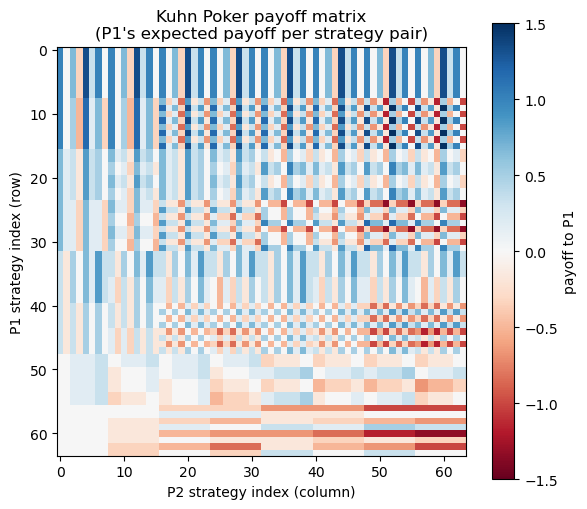

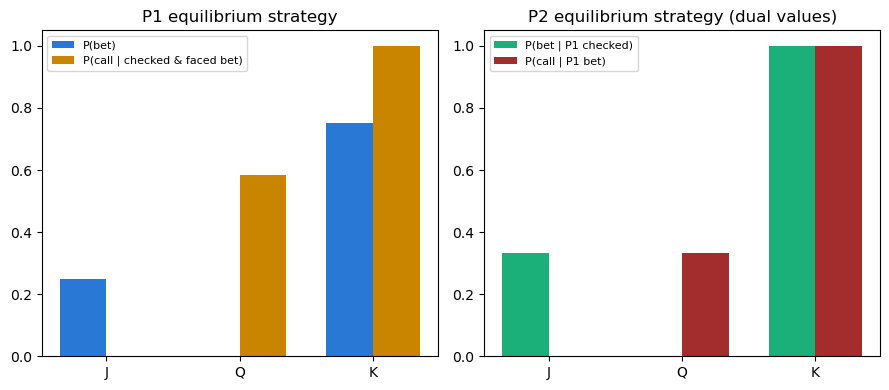

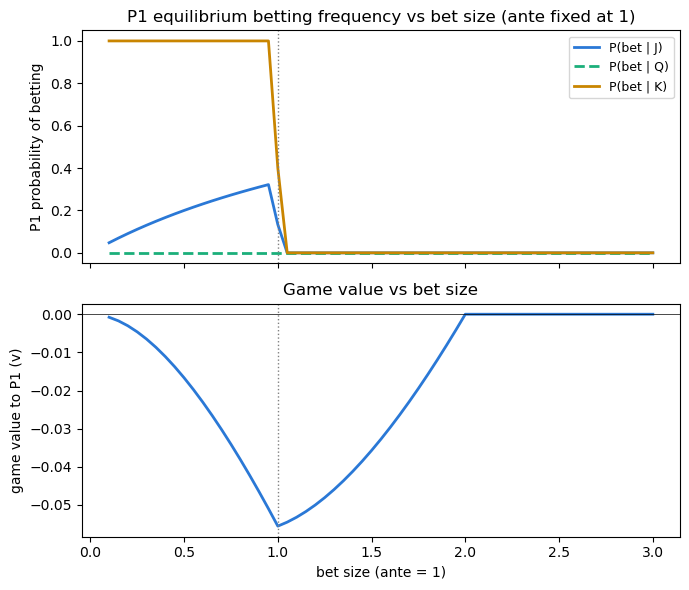

In [22]:
#AI used for visuals (Claude - Sonnet 4.6)

import numpy as np
import matplotlib.pyplot as plt


def plot_payoff_heatmap(matrix):
    """Heatmap of the full payoff matrix, diverging colormap centered at 0."""
    vmax = np.abs(matrix).max()
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(matrix, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="equal")
    ax.set_xlabel("P2 strategy index (column)")
    ax.set_ylabel("P1 strategy index (row)")
    ax.set_title("Kuhn Poker payoff matrix\n(P1's expected payoff per strategy pair)")
    fig.colorbar(im, ax=ax, shrink=0.8, label="payoff to P1")
    fig.tight_layout()
    plt.show()


def plot_equilibrium_bars(p1_agg, p2_agg):
    """Grouped bar chart of the solved per-card equilibrium probabilities."""
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    x_pos = np.arange(len(CARDS))
    width = 0.35

    bet_vals = [p1_agg["bet_prob"][c] for c in CARDS]
    call_vals = [p1_agg["call_prob"][c] if p1_agg["call_prob"][c] is not None else 0 for c in CARDS]
    axes[0].bar(x_pos - width / 2, bet_vals, width, label="P(bet)", color="#2a78d6")
    axes[0].bar(x_pos + width / 2, call_vals, width, label="P(call | checked & faced bet)", color="#c98500")
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(CARDS)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_title("P1 equilibrium strategy")
    axes[0].legend(fontsize=8)

    bet_vc = [p2_agg["bet_prob_vs_check"][c] for c in CARDS]
    call_vb = [p2_agg["call_prob_vs_bet"][c] for c in CARDS]
    axes[1].bar(x_pos - width / 2, bet_vc, width, label="P(bet | P1 checked)", color="#1baf7a")
    axes[1].bar(x_pos + width / 2, call_vb, width, label="P(call | P1 bet)", color="#a32d2d")
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(CARDS)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("P2 equilibrium strategy (dual values)")
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()


def run_bet_sweep(bet_sizes):
    """Re-solves the LP at each bet size, collecting the per-card breakdown for plotting."""
    p1_strats = all_p1_strategies()
    p2_strats = all_p2_strategies()

    betJ, betQ, betK, values = [], [], [], []
    for b in bet_sizes:
        matrix = build_payoff_matrix_np_b(p1_strats, p2_strats, bet=b)
        x, v, y, w, res = solve_primal_lp(matrix)
        agg = aggregate_p1_strategy(x, p1_strats)
        betJ.append(agg["bet_prob"]["J"])
        betQ.append(agg["bet_prob"]["Q"])
        betK.append(agg["bet_prob"]["K"])
        values.append(v)

    return {
        "bet_sizes": np.array(bet_sizes),
        "betJ": np.array(betJ), "betQ": np.array(betQ), "betK": np.array(betK),
        "v": np.array(values),
    }


def plot_bet_sweep(sweep_data):
    """Two-panel plot: per-card betting probability and game value vs bet size."""
    bets = sweep_data["bet_sizes"]

    fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    axes[0].plot(bets, sweep_data["betJ"], label="P(bet | J)", color="#2a78d6", linewidth=2)
    axes[0].plot(bets, sweep_data["betQ"], label="P(bet | Q)", color="#1baf7a", linewidth=2, linestyle="--")
    axes[0].plot(bets, sweep_data["betK"], label="P(bet | K)", color="#c98500", linewidth=2)
    axes[0].axvline(1.0, color="gray", linewidth=1, linestyle=":")
    axes[0].set_ylabel("P1 probability of betting")
    axes[0].set_title("P1 equilibrium betting frequency vs bet size (ante fixed at 1)")
    axes[0].legend(loc="upper right", fontsize=9)
    axes[0].set_ylim(-0.05, 1.05)

    axes[1].plot(bets, sweep_data["v"], color="#2a78d6", linewidth=2)
    axes[1].axvline(1.0, color="gray", linewidth=1, linestyle=":")
    axes[1].axhline(0, color="black", linewidth=0.5)
    axes[1].set_xlabel("bet size (ante = 1)")
    axes[1].set_ylabel("game value to P1 (v)")
    axes[1].set_title("Game value vs bet size")

    fig.tight_layout()
    plt.show()


# --- Run it, using the pipeline's own solver ---
solution = solve_kuhn_poker(verbose=False)

plot_payoff_heatmap(solution["matrix"])
plot_equilibrium_bars(solution["p1_agg"], solution["p2_agg"])

sweep_data = run_bet_sweep(np.arange(0.1, 3.01, 0.05))
plot_bet_sweep(sweep_data)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


def sample_action(prob_of_action_a, action_a, action_b):
    """
    Flip a biased coin and return one of two actions.
    e.g. sample_action(0.25, "bet", "check") returns "bet"
    25% of the time and "check" 75% of the time.
    """
    return action_a if np.random.random() < prob_of_action_a else action_b



In [25]:

def simulate_one_hand(p1_mixed, p2_mixed):
    """
    Play one hand of Kuhn poker by:
      1. Randomly dealing cards
      2. Having each player sample an action from their equilibrium
         mixed strategy (rather than averaging over all possibilities
         like mixed_expected_payoff does)
    Returns P1's chip payoff for this single hand.
    """
    # Step 1: random deal -- shuffle and take first two cards
    deck = list(CARDS)
    np.random.shuffle(deck)
    p1c, p2c = deck[0], deck[1]

    pot = 2
    p1_contrib = 1

    # Step 2: P1 opens -- bet with prob bet_prob[p1c], else check
    p1_bets = np.random.random() < p1_mixed["bet_prob"][p1c]

    if p1_bets:
        pot += 1
        p1_contrib += 1
        # P2 responds to a bet
        p2_calls = np.random.random() < p2_mixed["call_prob_vs_bet"][p2c]
        if not p2_calls:
            return pot - p1_contrib          # P2 folds, P1 takes pot
        else:
            pot += 1
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib

    else:
        # P2 responds to a check
        p2_bets = np.random.random() < p2_mixed["bet_prob_vs_check"][p2c]
        if not p2_bets:
            # Both check, straight to showdown
            p1_wins = RANK[p1c] > RANK[p2c]
            return (pot - p1_contrib) if p1_wins else -p1_contrib
        else:
            pot += 1
            # P1 responds to P2's bet
            p1_calls = np.random.random() < p1_mixed["call_prob"][p1c]
            if not p1_calls:
                return -p1_contrib           # P1 folds
            else:
                pot += 1
                p1_contrib += 1
                p1_wins = RANK[p1c] > RANK[p2c]
                return (pot - p1_contrib) if p1_wins else -p1_contrib



In [26]:

def run_simulation(n_hands, alpha=1/6, seed=42):
    """
    Simulate n_hands of Kuhn poker under the Nash equilibrium
    strategy parameterised by alpha, returning:
      - payoffs: raw per-hand payoffs (length n_hands)
      - running_mean: cumulative average after each hand
      - running_ci: 95% confidence interval half-width at each hand
    """
    np.random.seed(seed)
    p1_eq, p2_eq = kuhn_equilibrium(alpha)

    payoffs = np.array([
        simulate_one_hand(p1_eq, p2_eq)
        for _ in range(n_hands)
    ])

    running_mean = np.cumsum(payoffs) / np.arange(1, n_hands + 1)

    # 95% CI half-width: 1.96 * std / sqrt(n)
    running_std = np.array([
        payoffs[:i+1].std() for i in range(n_hands)
    ])
    running_ci = 1.96 * running_std / np.sqrt(np.arange(1, n_hands + 1))

    return payoffs, running_mean, running_ci



In [27]:

def plot_convergence(running_mean, running_ci, true_value=-1/18):
    """
    Plot the running average payoff with 95% CI band converging
    toward the theoretical game value (true_value).
    """
    n = len(running_mean)
    hands = np.arange(1, n + 1)

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.fill_between(
        hands,
        running_mean - running_ci,
        running_mean + running_ci,
        alpha=0.2, color="#2a78d6", label="95% CI"
    )
    ax.plot(hands, running_mean, color="#2a78d6", linewidth=1.5, label="simulated average")
    ax.axhline(true_value, color="#a32d2d", linewidth=1.5,
               linestyle="--", label=f"true value (−1/18 = {true_value:.4f})")
    ax.axhline(0, color="black", linewidth=0.5)

    ax.set_xscale("log")
    ax.set_xlabel("number of hands simulated (log scale)")
    ax.set_ylabel("P1 average payoff per hand")
    ax.set_title("Monte Carlo convergence to Nash equilibrium game value")
    ax.legend(fontsize=9)
    fig.tight_layout()
    display(fig)
    plt.close(fig)




     Hands    Simulated avg    True value       Error
----------------------------------------------------
       100         -0.15000      -0.05556     0.09444
       500         -0.07200      -0.05556     0.01644
      1000         -0.10900      -0.05556     0.05344
      5000         -0.07740      -0.05556     0.02184
     10000         -0.07920      -0.05556     0.02364
     10000         -0.07920      -0.05556     0.02364


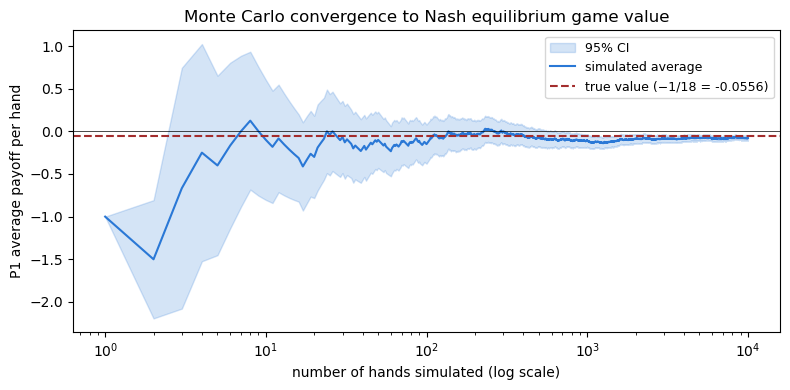

In [28]:

def print_simulation_summary(payoffs, running_mean, true_value=-1/18):
    """Print a short table of how the estimate looks at key checkpoints."""
    checkpoints = [100, 500, 1000, 5000, 10000, len(payoffs)]
    checkpoints = [c for c in checkpoints if c <= len(payoffs)]

    print(f"\n{'Hands':>10}  {'Simulated avg':>15}  {'True value':>12}  {'Error':>10}")
    print("-" * 52)
    for n in checkpoints:
        avg = running_mean[n - 1]
        err = abs(avg - true_value)
        print(f"{n:>10}  {avg:>15.5f}  {true_value:>12.5f}  {err:>10.5f}")


# --- Run it ---
N_HANDS = 10_000
payoffs, running_mean, running_ci = run_simulation(N_HANDS, alpha=1/6)

print_simulation_summary(payoffs, running_mean)
plot_convergence(running_mean, running_ci)